# Option A Exploration

This notebook contains the exploration component for Option A, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful staring points for the extension include:_
* **Advanced filter methods:** Build on the filters from this notebook to  emulate filters from social media or photo-editing apps!
* **Advanced image recognition techniques:** Extend the object detection problem to be more general, handle more objects, etx

For more detailed instructions, please see the [Project 1 Guidelines](https://docs.google.com/document/d/1_yLzSePaVH2OrQgzZsu-1sZ4ez1Da9_tFzZFM3LCarQ/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1:
* Source 2:
* Source 3:
* Source 4:
* Source 5:

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
!git clone https://github.com/gaoruosong/CS131_release.git

Cloning into 'CS131_release'...
remote: Enumerating objects: 2720, done.
remote: Counting objects: 100% (391/391), done.
remote: Compressing objects: 100% (307/307), done.
remote: Total 2720 (delta 278), reused 84 (delta 84), pack-reused 2329 (from 3)
Receiving objects: 100% (2720/2720), 185.59 MiB | 31.65 MiB/s, done.
Resolving deltas: 100% (796/796), done.


In [2]:
%pwd

'/content'

In [3]:
%cd CS131_release/spring_2026/project1_release/option_A

/content/CS131_release/spring_2026/project1_release/option_A


In [4]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from time import time
from skimage import io




%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

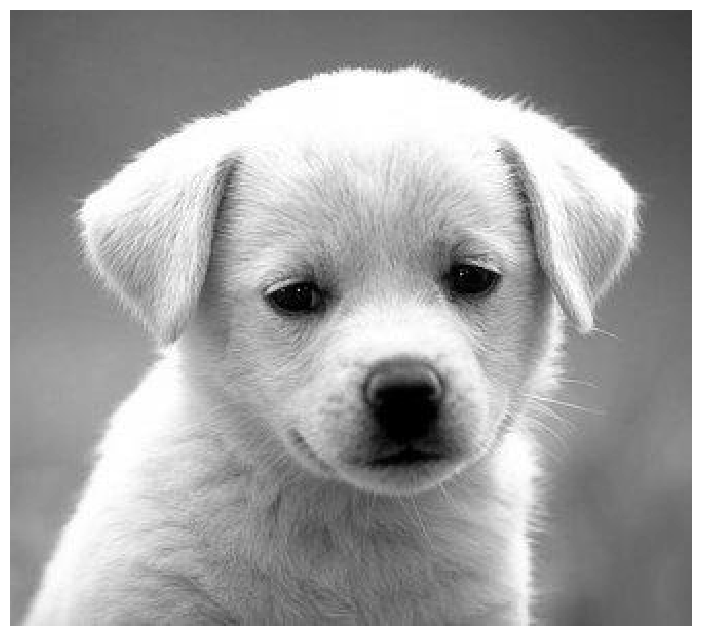

In [6]:
# Open image as grayscale
dog_img = io.imread('dog.jpg', as_gray=True)

# Show image
plt.imshow(dog_img)
plt.axis('off')
plt.show()

In [ ]:
# Part (1): helper functions & default filters

import math

def zero_pad(image, pad_height, pad_width):
    """ Zero-pad an image.

    Ex: a 1x1 image [[1]] with pad_height = 1, pad_width = 2 becomes:

        [[0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0]]         of shape (3, 5)

    Args:
        image: numpy array of shape (H, W).
        pad_width: width of the zero padding (left and right padding).
        pad_height: height of the zero padding (bottom and top padding).

    Returns:
        out: numpy array of shape (H+2*pad_height, W+2*pad_width).
    """

    H, W = image.shape
    out = None

    out = np.zeros((H + 2*pad_height, W + 2*pad_width))
    for i in range(H):
        for j in range(W):
            out[i + pad_height][j + pad_width] = image[i][j]

    return out


def conv_fast(image, kernel):
    """ An efficient implementation of convolution filter.

    This function uses element-wise multiplication and np.sum()
    to efficiently compute weighted sum of neighborhood at each
    pixel.

    Hints:
        - Use the zero_pad function you implemented above
        - There should be two nested for-loops
        - You may find np.flip() and np.sum() useful

    Args:
        image: numpy array of shape (Hi, Wi).
        kernel: numpy array of shape (Hk, Wk). Dimensions will be odd.

    Returns:
        out: numpy array of shape (Hi, Wi).
    """
    Hi, Wi = image.shape
    Hk, Wk = kernel.shape
    out = np.zeros((Hi, Wi))

    mid_height = int(Hk/2)
    mid_width = int(Wk/2)
    padded_image = zero_pad(image, mid_height, mid_width)
    flipped_kernel = np.flip(kernel)
    for i in range(mid_height, Hi+mid_height):
        for j in range(mid_width, Wi+mid_width):
            patch = padded_image[i-Hk+mid_height+1:i+mid_height+1, j-Wk+mid_width+1:j+mid_width+1] ## important! slicing must be done in one step.
            out[i-mid_height][j-mid_width] = np.sum(patch * flipped_kernel)

    return out


## for small sizes, binomial filters should work just as fine as Gaussian kernel
def binomial_filter(size = 3):
  ## builds a binomial filter of dimensions size x size
  out = np.zeros((size,size))
  for i in range(size):
    for j in range(size):  ## double for loop not the most efficient, but for all practical inputs, this is completely fine
      out[i][j] = math.comb(size, i) * math.comb(size, j)
  return out


def efficient_binomial(size = 3):
  ## builds a binomial filter of dimensions size x size, using more numpy functionalities
  column = np.zeros((size, 1))
  row = np.zeros((1, size))
  for i in range(size):
    column[i][0] = math.comb(size, i)
    row[0][i] = math.comb(size, i)
  return np.matmul(column, row)


def brighten_image(image, size = 3):
  ## takes in an image and replaces each pixel with the maximal value in a centered size x size patch
  ## assumption: size << image dimensions, otherwise this function is very inefficient
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]     ## also slightly inefficient, can probably skip padding
      out[i-half][j-half] = np.max(patch)

  return out


def brighten_image(image, size = 3):
  ## takes in an image and replaces each pixel with the minimal value in a centered size x size patch
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      patch = padded_image[i-half:i+size-half, j-half:j+size-half]
      out[i-half][j-half] = np.min(patch)

  return out



def standard_sobel_filters(size = 3):
  ## builds Sobel filters. Returns a horizontal one and a vertical one.
  out_horizontal = np.zeros((size, 3))
  out_vertical = np.zeros((3, size))
  for i in range(size):
    out_horizontal[i][0] = -math.comb(size, i)
    out_horizontal[i][2] = math.comb(size, i)
    out_vertical[0][i] = -math.comb(size, i)
    out_vertical[2][i] = math.comb(size, i)

  return out_horizontal, out_vertical


def detect_edge(image, size = 3):
  ## uses sobel filters to detect edges
  out = np.zeros(image.shape)
  half = size//2
  padded_image = zero_pad(image, half, half)
  horizontal, vertical = standard_sobel_filters(size)
  for i in range(half, image.shape[0]+half):
    for j in range(half, image.shape[1]+half):
      horizontal_patch = padded_image[i-half:i+size-half, j-1:j+2]
      vertical_patch = padded_image[i-1:i+2, j-half:j+size-half]
      Gx = np.sum(horizontal_patch * horizontal)
      Gy = np.sum(vertical_patch * vertical)
      out[i-half][j-half] = np.sqrt(Gx**2 + Gy**2)

  return out


def enhance_image(image):
  ## this one only accommodates enhancing in 3x3 area.
  kernel = [[0,-1,0],[-1,5,-1],[0,-1,0]]
  padded_image = zero_pad(image, 1, 1)
  out = np.zeros(image.shape)
  for i in range(1, image.shape[0]+1):
    for j in range(1, image.shape[1]+1):
      patch = padded_image[i-1:i+2, j-1:j+2]
      out[i-1][j-1] = np.sum(patch * kernel)
  return out

In [ ]:
## testing basic helpers

enhanced_dog = enhance_image(dog_img)
sobel_dog = detect_edge(dog_img)
brighten_dog = brighten_image(dog_img)

plt.subplot(1,3,1)
plt.imshow(enhanced_dog)
plt.title('enhanced dog')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sobel_dog)
plt.title('sobel dog')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(brighten_dog)
plt.title('bright dog')
plt.axis('off')

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_